### Data Mining with Prinicipal Component Analysis (PCA)

By Stephanie Nguyen

### A1. PROPOSAL OF QUESTION
How does dimensionality reduction in churn data enhance decision-making and customer understanding for telecom companies?

### A2. DEFINED GOAL
Principal Component Analysis (PCA) is employed to reduce the number of features, isolating the most significant ones. This allows telecommunications companies to create more targeted marketing strategies, ultimately improving customer retention and driving long-term profitability. 

### B1.EXPLANATION OF PCA
To simplify the telecom churn dataset, Principal Component Analysis was used as both a machine learning and dimensionality reduction technique. 

### B2. PCA ASSUMPTION
PCA is a method for reducing dimensions based on the idea that the relationships in the data are linear, which helps it capture variance along straight lines. 

### PACKAGES AND LIBRARIES LIST


In [ ]:
# Importing all libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For scaling and PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

In [ ]:
pip install openpyxl

In [ ]:
# Load Data
# import churn_clean.csv data set
df = pd.read_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\10. PCA for Dimensionality Reduction (Python)\Data\churn_clean.csv", keep_default_na=False,na_values=['NaN'])

### DATA PREPROCESSING

In [ ]:
# Get the number of rows and columns in the dataframe
df.shape

(10000, 50)

In [ ]:
# preview the data
pd.set_option('display.max_columns',None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [ ]:
# get overview of columns and data types in dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [ ]:
# detect null values
df.isnull().sum()

CaseOrder               0
Customer_id             0
Interaction             0
UID                     0
City                    0
State                   0
County                  0
Zip                     0
Lat                     0
Lng                     0
Population              0
Area                    0
TimeZone                0
Job                     0
Children                0
Age                     0
Income                  0
Marital                 0
Gender                  0
Churn                   0
Outage_sec_perweek      0
Email                   0
Contacts                0
Yearly_equip_failure    0
Techie                  0
Contract                0
Port_modem              0
Tablet                  0
InternetService         0
Phone                   0
Multiple                0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
PaperlessBilling        0
PaymentMetho

In [ ]:
# get duplicates across all columns
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

### C1. CONTINUOUS DATA SET VARIABLES

In [ ]:
df_subset = df.select_dtypes('float64')
df_subset

,Lat,Lng,Income,Outage_sec_perweek,Tenure,MonthlyCharge,Bandwidth_GB_Year
0,56.25100,-133.37571,28561.99,7.978323,6.795513,172.455519,904.536110
1,44.32893,-84.24080,21704.77,11.699080,1.156681,242.632554,800.982766
2,45.35589,-123.24657,9609.57,10.752800,15.754144,159.947583,2054.706961
3,32.96687,-117.24798,18925.23,14.913540,17.087227,119.956840,2164.579412
4,29.38012,-95.80673,40074.19,8.147417,1.670972,149.948316,271.493436
...,...,...,...,...,...,...,...
9995,43.43391,-72.78734,55723.74,9.415935,68.197130,159.979400,6511.252601
9996,36.56907,-87.41694,34129.34,6.740547,61.040370,207.481100,5695.951810
9997,35.52039,-100.44180,45983.43,6.590911,47.416890,169.974100,4159.305799
9998,33.58016,-85.13241,16667.58,12.071910,71.095600,252.624000,6468.456752


### C2. STANDARDIZATION OF DATA SET VARIABLES

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_subset)

In [ ]:
df_clean = pd.DataFrame(scaled_data, columns = df_subset.columns)
df_clean.head()

,Lat,Lng,Income,Outage_sec_perweek,Tenure,MonthlyCharge,Bandwidth_GB_Year
0,3.217410,-2.810432,-0.398778,-0.679978,-1.048746,-0.003943,-1.138487
1,1.024691,0.431644,-0.641954,0.570331,-1.262001,1.630326,-1.185876
2,1.213570,-2.142079,-1.070885,0.252347,-0.709940,-0.295225,-0.612138
3,-1.065031,-1.746273,-0.740525,1.650506,-0.659524,-1.226521,-0.561857
4,-1.724710,-0.331512,0.009478,-0.623156,-1.242551,-0.528086,-1.428184


### CLEANED DATA SET

In [ ]:
# View and export the cleaned data set
df_clean.to_csv(r"C:\Users\steph\Documents\GitHub\Data Analysis\10. PCA for Dimensionality Reduction (Python)\Outputs\df_clean.csv",index=False)

### D1. PRINCIPAL COMPONENTS

In [ ]:
pca = PCA()
pc = pca.fit_transform(df_clean)
loading_matrix = pd.DataFrame(pca.components_, columns = df_clean.columns, index = ('PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'))
loading_matrix

,Lat,Lng,Income,Outage_sec_perweek,Tenure,MonthlyCharge,Bandwidth_GB_Year
PC1,-0.023929,0.007948,0.003751,0.005784,0.705612,0.040770,0.706941
PC2,0.699473,-0.706476,0.072029,-0.026424,0.020180,-0.071391,0.015428
PC3,-0.122083,0.003629,0.330376,-0.687545,0.038144,-0.633843,-0.001818
PC4,0.024641,0.072063,0.904620,0.045709,-0.028709,0.415871,-0.000478
PC5,-0.034349,0.030741,0.257294,0.721765,0.034436,-0.639926,-0.006245
PC6,-0.702476,-0.703332,0.033327,0.059290,-0.014295,0.083492,-0.007080
PC7,0.001028,0.000755,-0.001254,0.000025,-0.705716,-0.045372,0.707038


In [ ]:
loading_matrix.to_excel('loading_matrix.xlsx')

In [ ]:
# create a numpy array of the principal components
PC = np.arange(pca.n_components_) + 1
PC

array([1, 2, 3, 4, 5, 6, 7])

In [ ]:
# percentage of explained variance in each component
exp_var = pca.explained_variance_ratio_
exp_var

array([0.28482577, 0.15730985, 0.14634016, 0.14256851, 0.1397677 ,
       0.12826582, 0.00092219])

### D2. IDENTIFICATION OF THE TOTAL NUMBER OF COMPONENTS

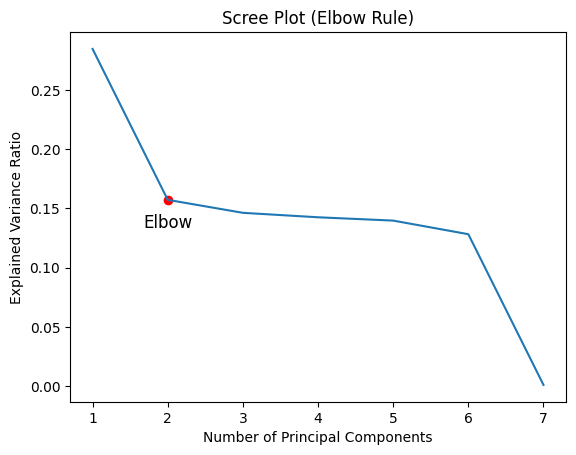

In [ ]:
# Elbow Method/ Scree Plot
plt.plot(PC, exp_var)
plt.title('Scree Plot (Elbow Rule)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.scatter(PC[1], exp_var[1], color='r')
plt.text(PC[1], exp_var[1]*0.85, 'Elbow', fontsize = 12, horizontalalignment = 'center')
plt.savefig('Scree Plot (Elbow Rule).png',bbox_inches='tight')
plt.show()

In [ ]:
print(dict(zip(['PC1', 'PC2'], PC)))

{'PC1': 1, 'PC2': 2}


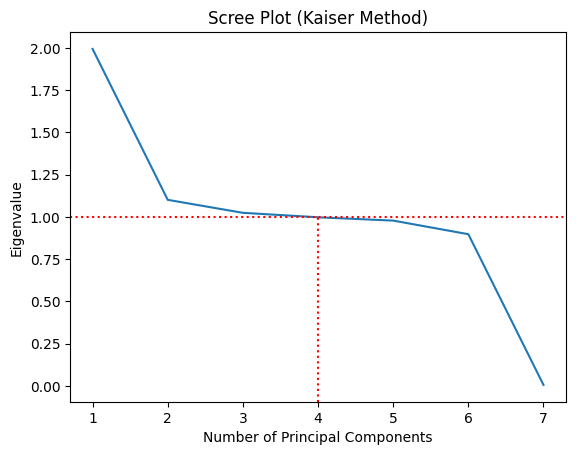

In [ ]:
# Kaiser Method
eigenvalues = pca.explained_variance_
plt.plot(PC, eigenvalues)
plt.axhline(y = 1, color = 'r', linestyle = ':')
plt.axvline(x = 4, ymin= 0, ymax = 0.5, color = 'r', linestyle = ':')
plt.title('Scree Plot (Kaiser Method)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Eigenvalue')
plt.savefig('Scree Plot (Kaiser Method).png',bbox_inches='tight')
plt.show()

In [ ]:
print(dict(zip(['PC1', 'PC2', 'PC3', 'PC4'], PC)))

{'PC1': 1, 'PC2': 2, 'PC3': 3, 'PC4': 4}


### D3. VARIANCE OF EACH COMPONENT

In [ ]:
print(pca.explained_variance_[:2])

[1.9939798  1.10127908]


In [ ]:
# the eigenvalues (variance) 
print(pca.explained_variance_[:4])

[1.9939798  1.10127908 1.02448354 0.9980794 ]


### D4. TOTAL VARIANCE CAPTURED BY COMPONENTS

In [ ]:
# total variance captured by 2 principal components
tot_var_cap = np.sum(pca.explained_variance_ratio_[:2])
tot_var_cap    

0.4421356228684935

In [ ]:
# total variance captured by 4 principal components
tot_var_cap = np.sum(pca.explained_variance_ratio_[:4])
tot_var_cap                

0.731044291439257

### D5. SUMMARY OF DATA ANALYSIS
The elbow rule suggested retaining two principal components, capturing only 44% of the variance, which was deemed insufficient.
The Kaiser method recommended retaining four components, accounting for 73% of the variance.